In [1]:
import sys
sys.path.append("..") # notebooks/ bir üst klasörden import için
from data.loader import load_uci_credit, get_shape_info

In [ ]:
#%pip install missingno #bunu  çalıştırdıktan sonra silip sadece requirement txt dosyasına ekleyeceğim.

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#bunu': Expected package name at the start of dependency specifier
    #bunu
    ^


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno 
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = load_uci_credit()
shape_info = get_shape_info(df)

In [5]:
df.head()

,id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_payment_next_month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [6]:
df.describe()

,id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_payment_next_month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


MİSSİNG VALUE ANALİZİ

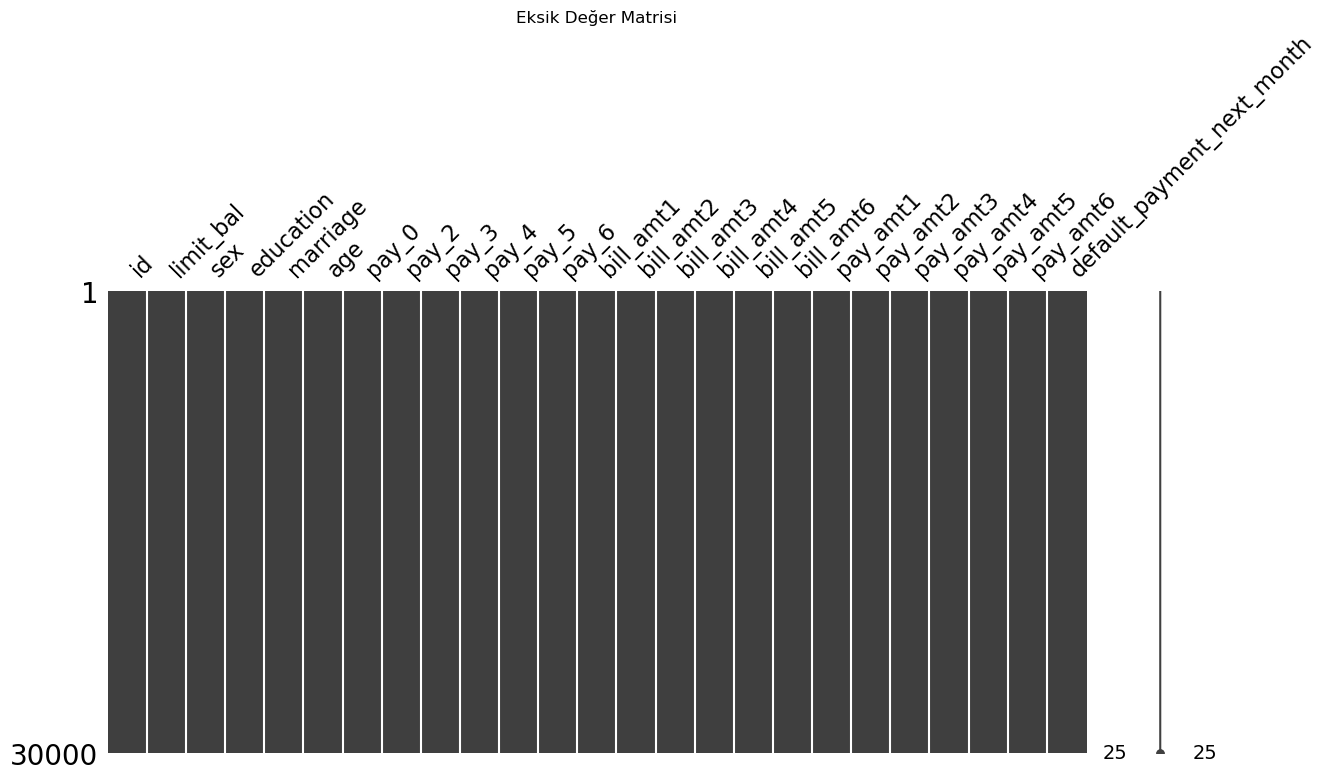

In [7]:
# Eksik değer matrisi
msno.matrix(df, figsize=(14, 6))
plt.title("Eksik Değer Matrisi")
plt.show()

Hedef değişken dağılım grafiği

Text(0.5, 1.0, 'Distribution of Target Variable')

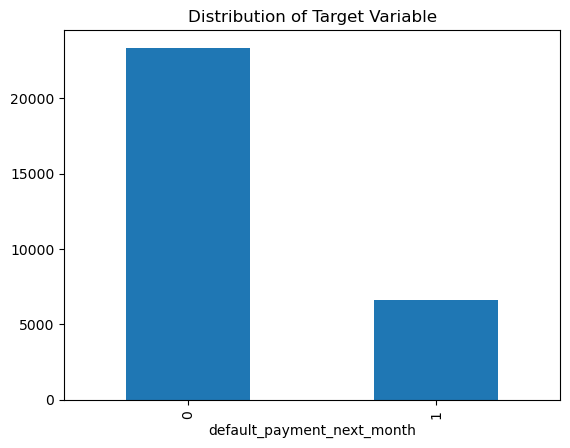

In [8]:
df["default_payment_next_month"].value_counts().plot(kind="bar")
plt.title("Distribution of Target Variable")

In [9]:
"""for col in df.columns:
    if df[col].dtype == "object":
        sns.countplot(x=col, data=df)
        plt.title(f"Distribution of {col}")
        plt.xticks(rotation=45)
        plt.show()"""

'for col in df.columns:\n    if df[col].dtype == "object":\n        sns.countplot(x=col, data=df)\n        plt.title(f"Distribution of {col}")\n        plt.xticks(rotation=45)\n        plt.show()'

AYKIRI DEĞER ANALİZİ

In [10]:
#histogram ve boxplot ile sayısal değişkenlerin dağılımını incelemeden önce df numeric oluşturdum
df_numeric = df.select_dtypes(include=["int64", "float64"])

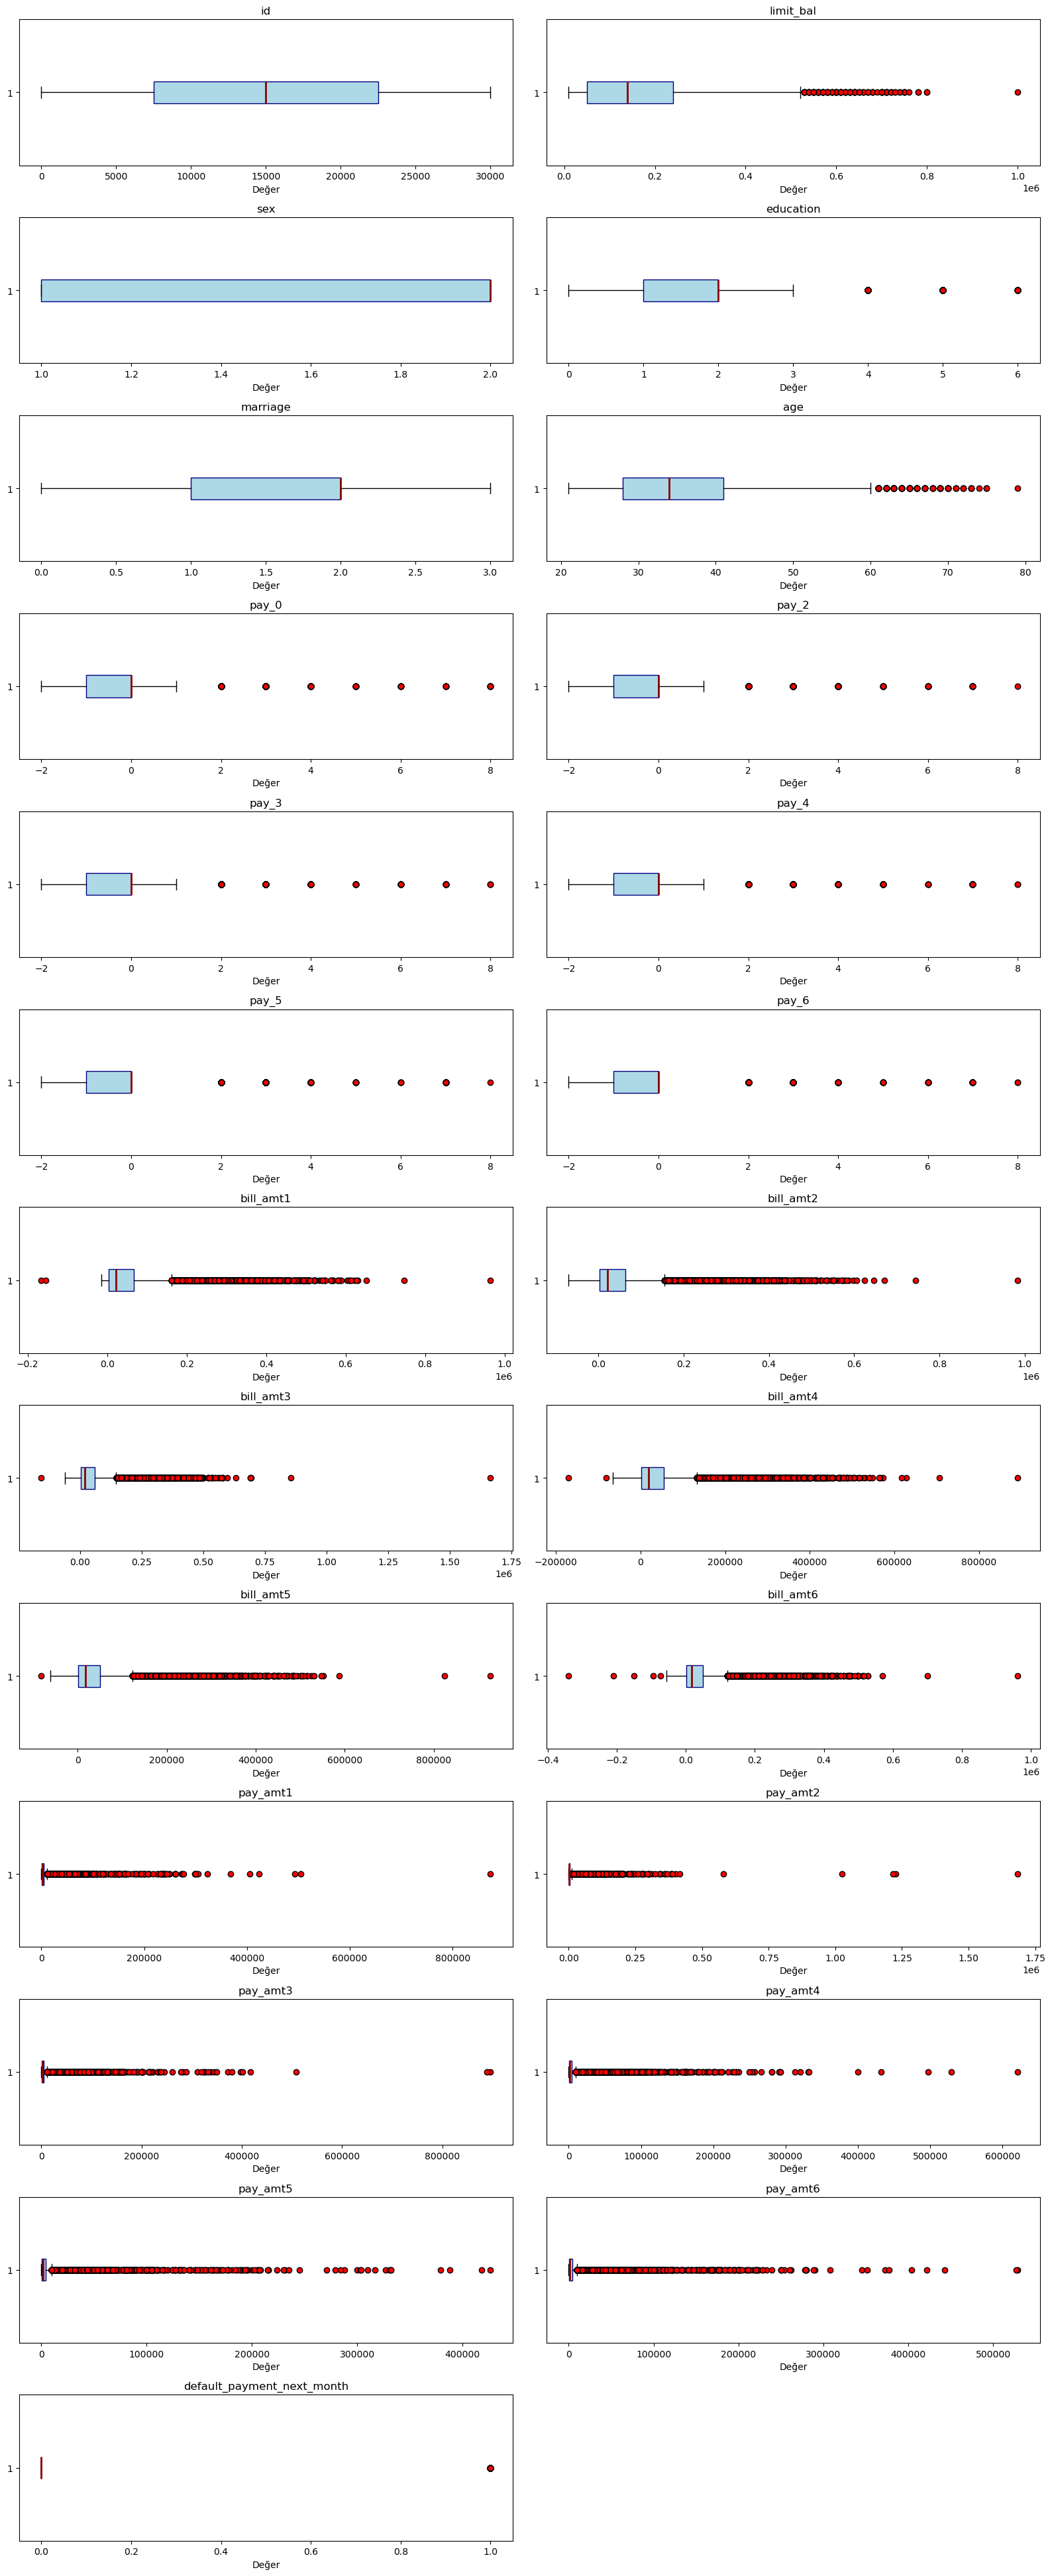

In [11]:
import math

cols = 2
rows = math.ceil(len(df_numeric.columns) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3))
axes = axes.flatten()

for idx, col in enumerate(df_numeric.columns):
    axes[idx].boxplot(df_numeric[col], vert=False, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', color='navy'),
                      flierprops=dict(marker='o', markerfacecolor='red', markersize=6),
                      medianprops=dict(color='darkred', linewidth=2))
    axes[idx].set_title(f'{col}', fontsize=12)
    axes[idx].set_xlabel('Değer')


for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

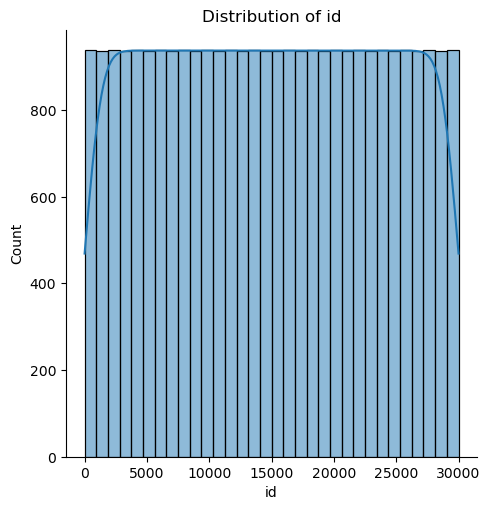

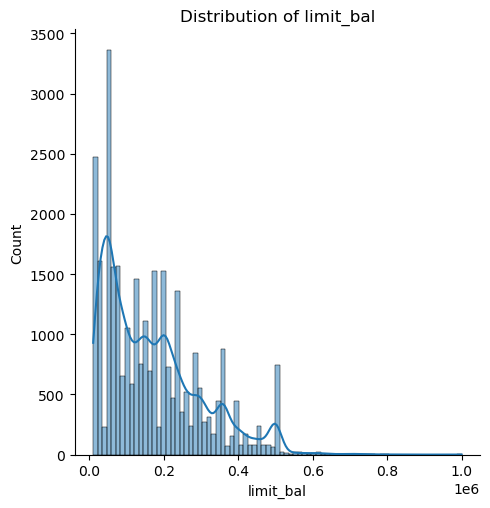

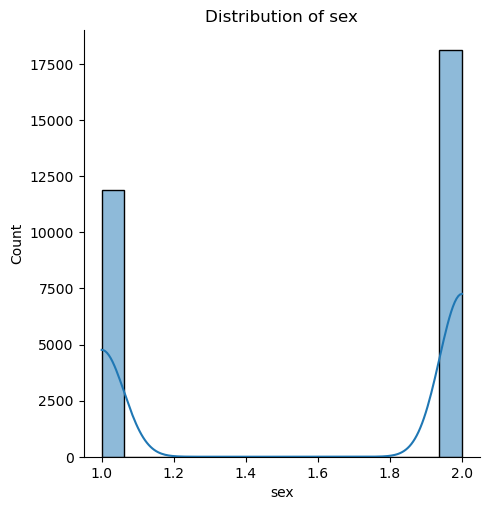

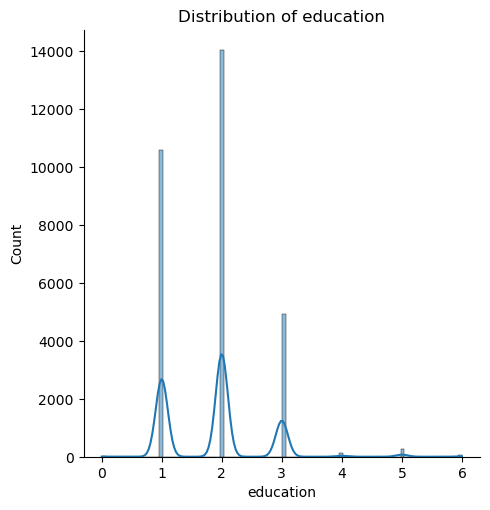

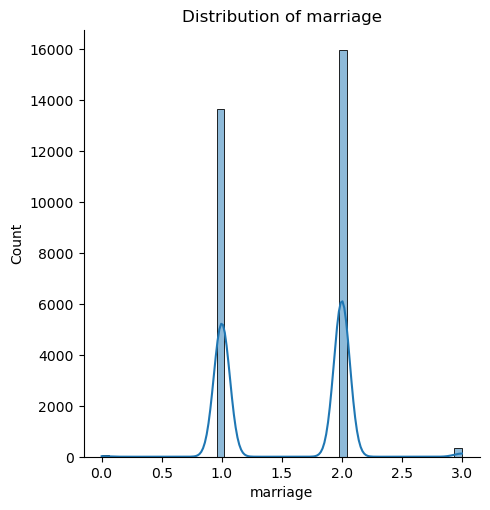

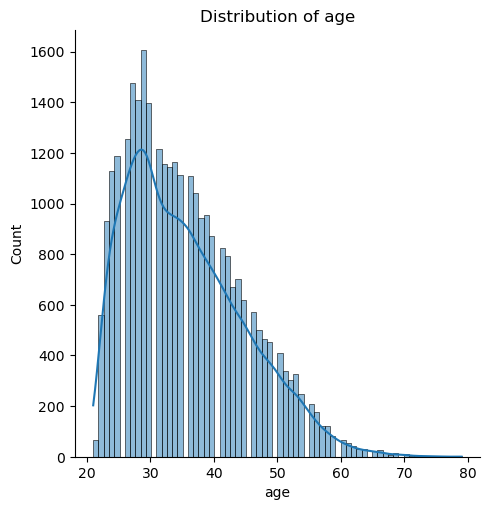

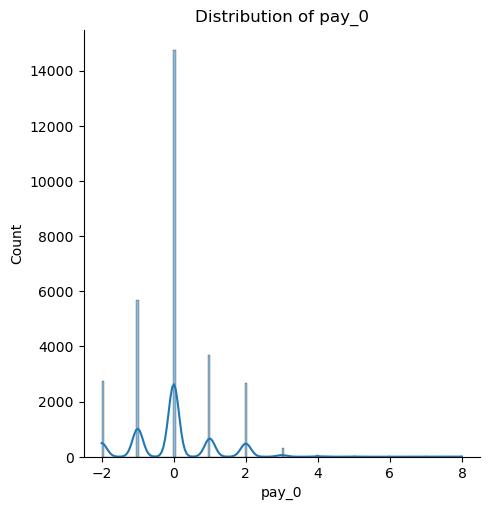

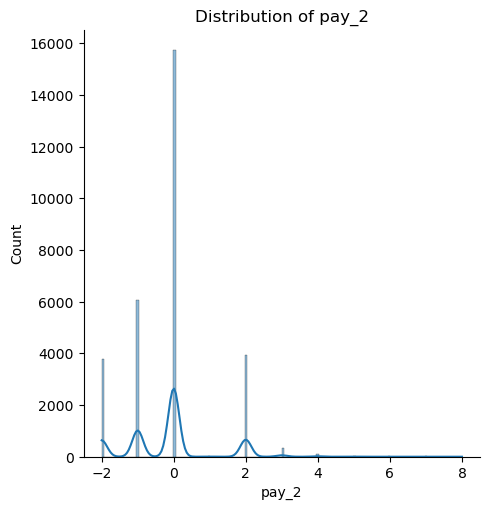

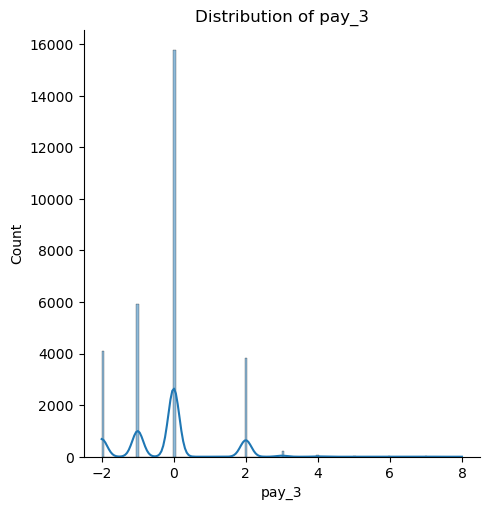

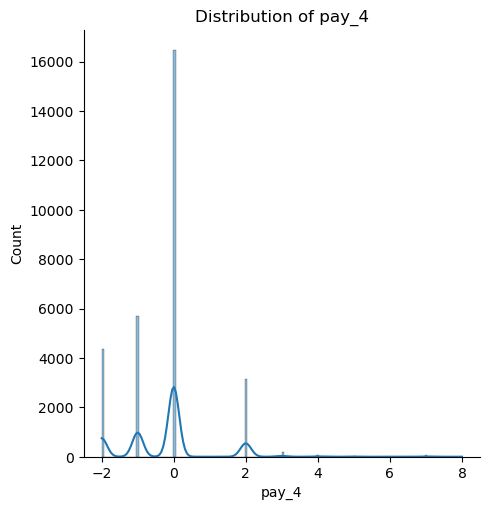

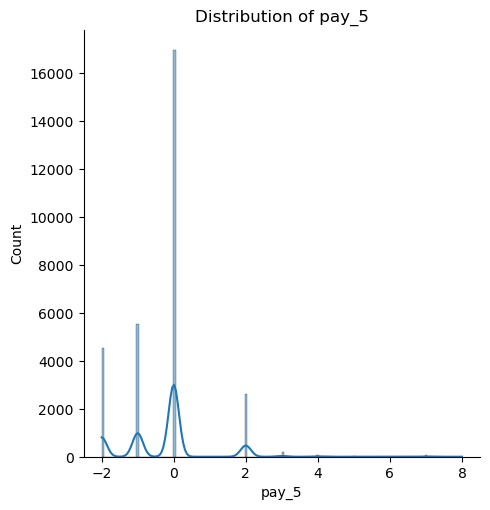

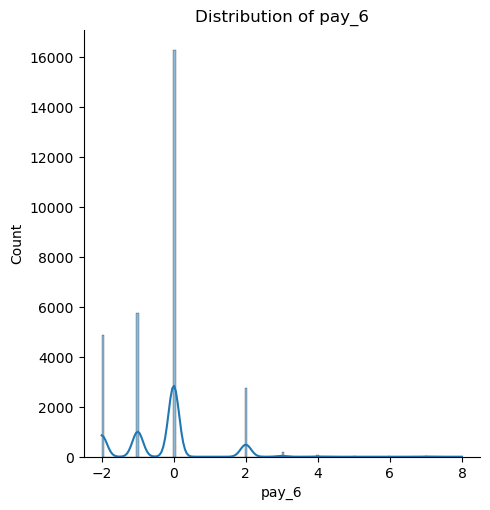

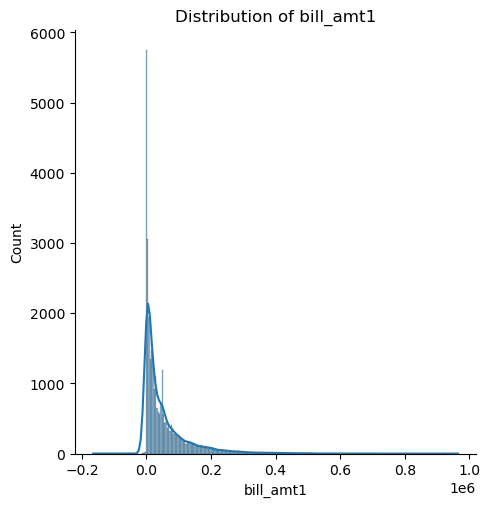

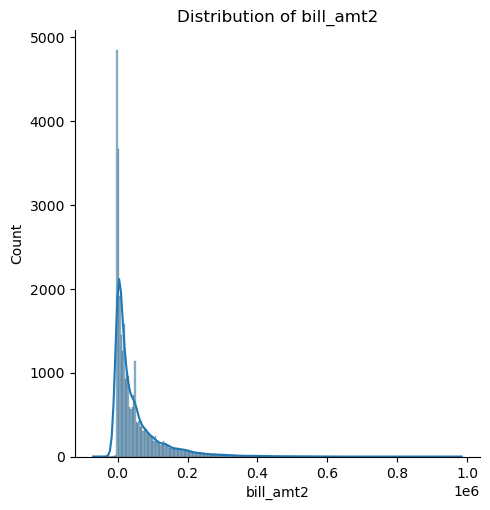

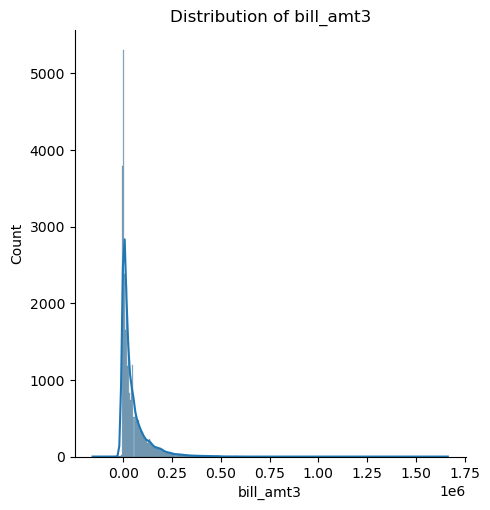

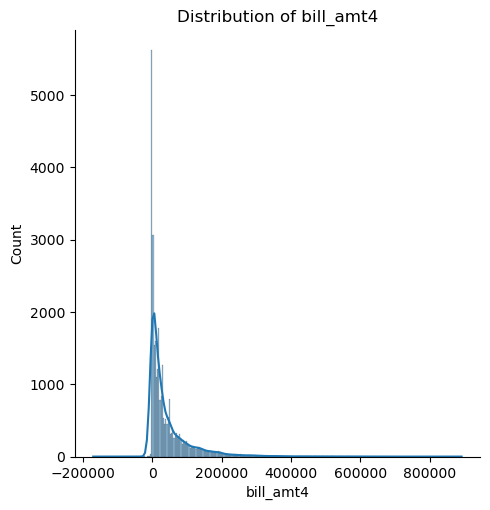

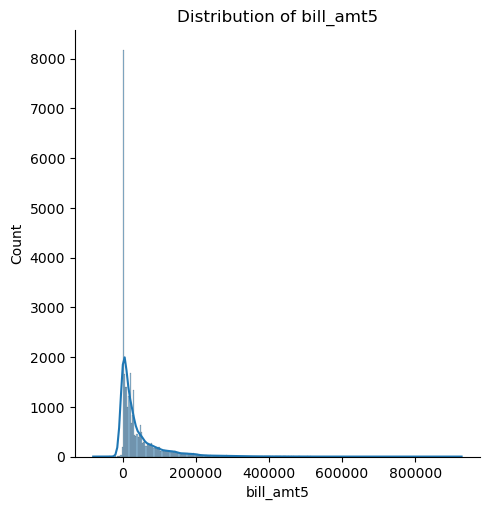

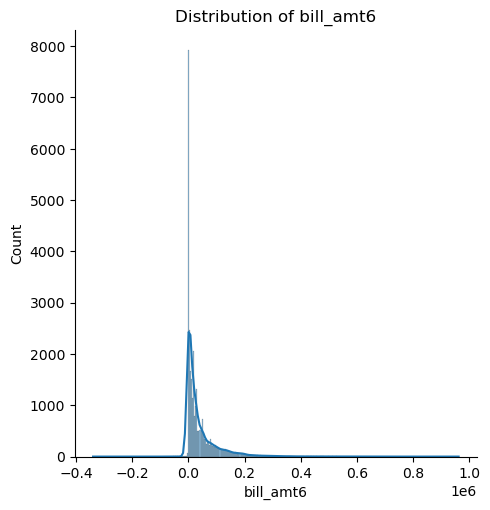

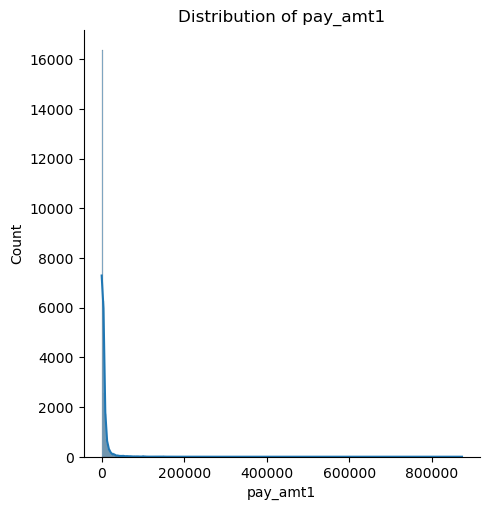

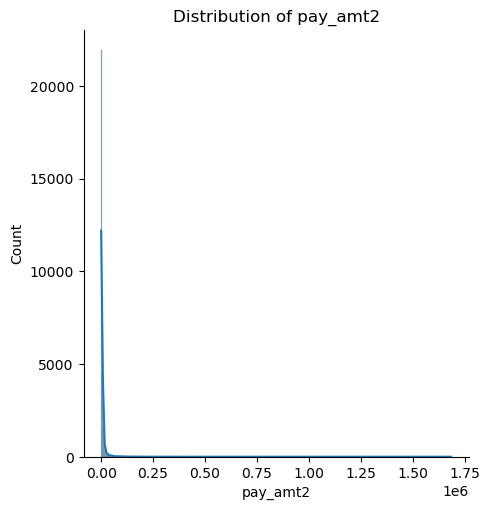

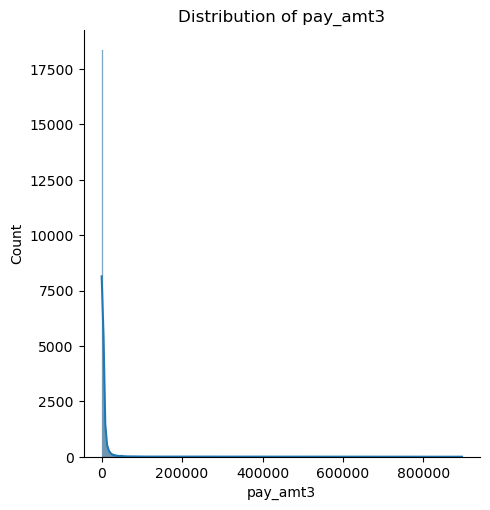

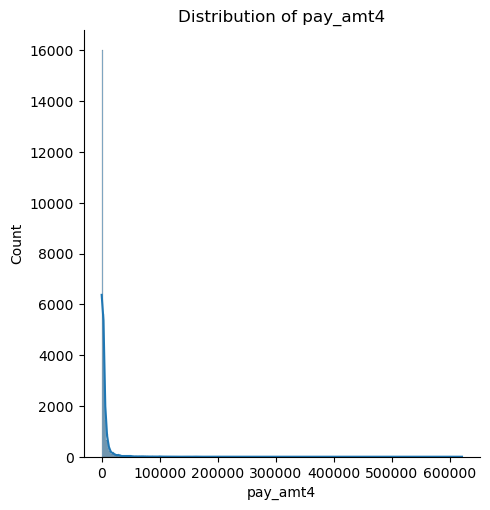

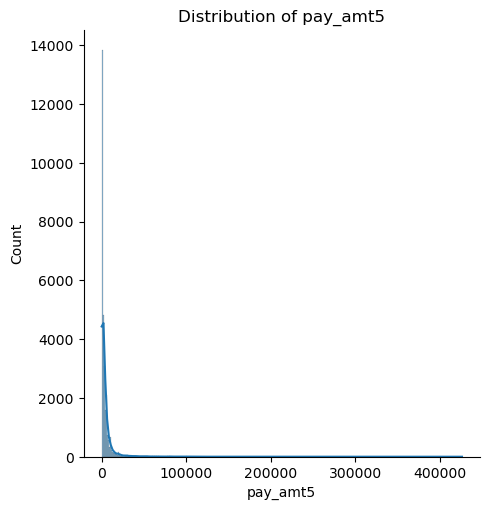

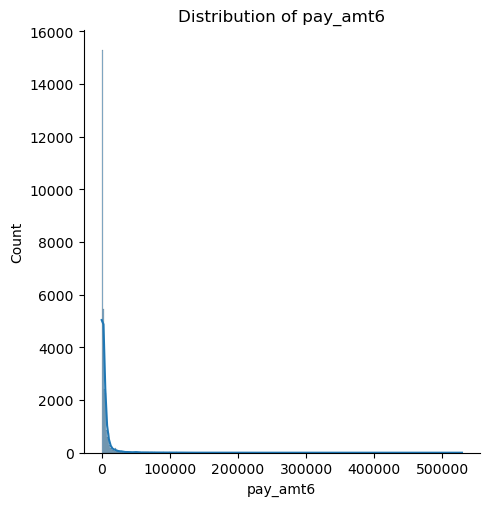

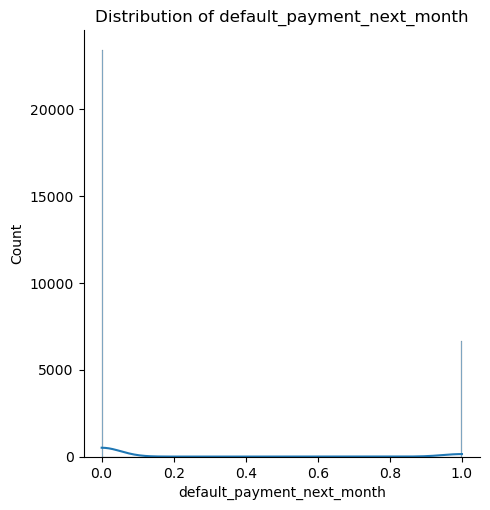

In [12]:
#sns.displot(df["LIMIT_BAL"], kde=True) 
#--- HER SAYISAL DEĞERİN HİSTOGRAMINI GÖSTERMEK İÇİN ---
for col in df.columns:
    if df[col].dtype in ["int64", "float64"]:
        sns.displot(df[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

In [20]:
#id ile işimiz olmadığından dolayı onu kaldırıyorum
df.drop("id", axis=1, inplace=True)

<Axes: >

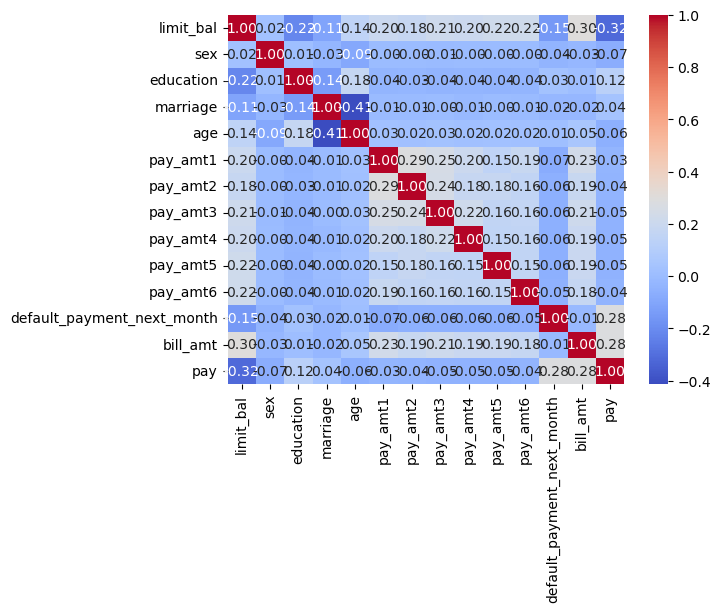

In [21]:
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")

Yüksek korelasyonlu featurlar birleştirildi

In [22]:
df["bill_amt"]=df[["bill_amt1", "bill_amt2", "bill_amt3", "bill_amt4", "bill_amt5", "bill_amt6"]].sum(axis=1)
df.drop(columns=["bill_amt1", "bill_amt2", "bill_amt3", "bill_amt4", "bill_amt5", "bill_amt6"], inplace=True)

KeyError: "None of [Index(['bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5',\n       'bill_amt6'],\n      dtype='object')] are in the [columns]"

<Axes: >

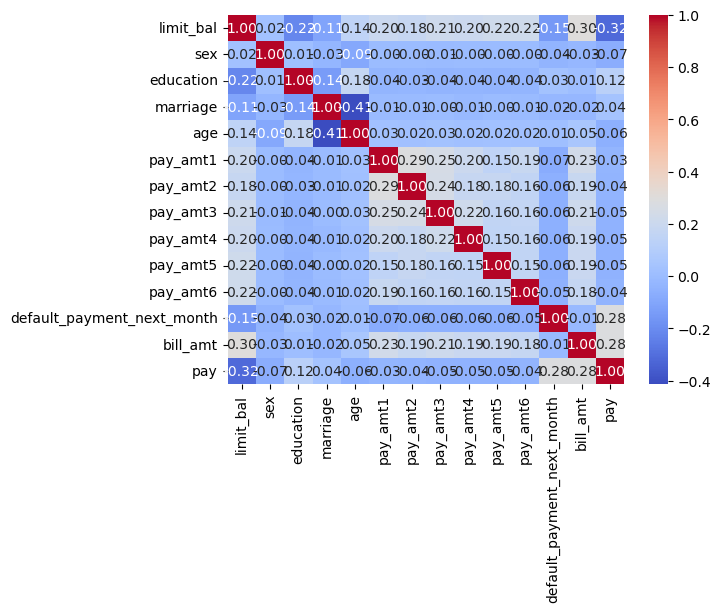

In [23]:
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")

In [24]:
df["pay"]=df[["pay_0", "pay_2", "pay_3", "pay_4", "pay_5", "pay_6"]].sum(axis=1)
df.drop(columns=["pay_0", "pay_2", "pay_3", "pay_4", "pay_5", "pay_6"], inplace=True)

KeyError: "None of [Index(['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6'], dtype='object')] are in the [columns]"

<Axes: >

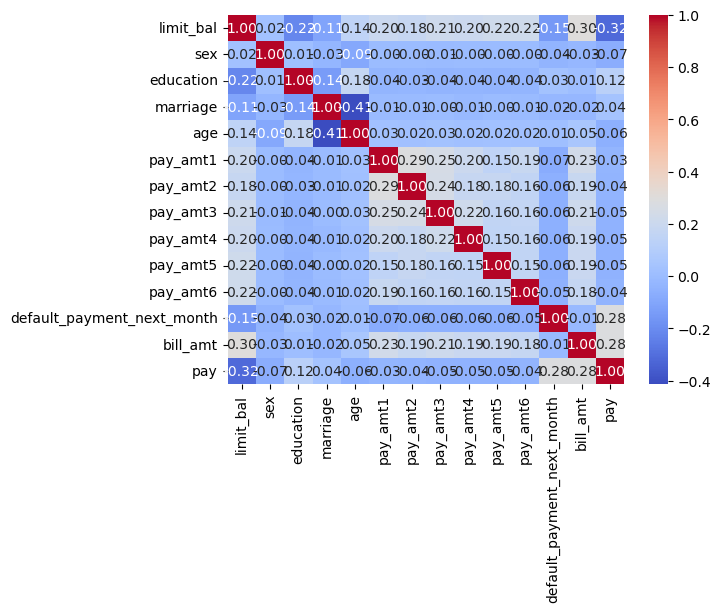

In [25]:
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")

In [26]:
# top 5 korelasyon
hedef_sutun = "default_payment_next_month"
top5=(
    df.corr()[hedef_sutun]
    .abs()
    .sort_values(ascending=False)
    .iloc[1:6] #.head(6)  # 6 çünkü kendisi de dahil
)
print("Top 5 Korelasyon:\n", top5)

Top 5 Korelasyon:
 pay          0.281955
limit_bal    0.153520
pay_amt1     0.072929
pay_amt2     0.058579
pay_amt4     0.056827
Name: default_payment_next_month, dtype: float64
